# 2D decaying turbulence


A simulation of decaying two-dimensional turbulence.

In [1]:
using FourierFlows, Printf, Random, Plots

using Random: seed!
using FFTW: rfft, irfft

import GeophysicalFlows.TwoDNavierStokes
import GeophysicalFlows.TwoDNavierStokes: energy, enstrophy
import GeophysicalFlows: peakedisotropicspectrum

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical, domain, and simulation parameters

First, we pick some numerical and physical parameters for our model.

In [3]:
n, L  = 128, 2π             # grid resolution and domain length
nothing # hide

# Then we pick the time-stepper parameters
    dt = 1e-2  # timestep
nsteps = 4000  # total number of steps
 nsubs = 20    # number of steps between each plot
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments. The
`stepper` keyword defines the time-stepper to be used.

In [4]:
prob = TwoDNavierStokes.Problem(dev; nx=n, Lx=L, ny=n, Ly=L, dt=dt, stepper="FilteredRK4")
nothing # hide

Next we define some shortcuts for convenience.

In [5]:
sol, cl, vs, gr = prob.sol, prob.clock, prob.vars, prob.grid
x, y = gr.x, gr.y
nothing # hide

## Setting initial conditions

Our initial condition closely tries to reproduce the initial condition used
in the paper by McWilliams (_JFM_, 1984)

In [6]:
seed!(1234)
k₀, E₀ = 6, 0.5
ζ₀ = peakedisotropicspectrum(gr, k₀, E₀, mask=prob.timestepper.filter)
TwoDNavierStokes.set_zeta!(prob, ζ₀)
nothing # hide

Let's plot the initial vorticity field:

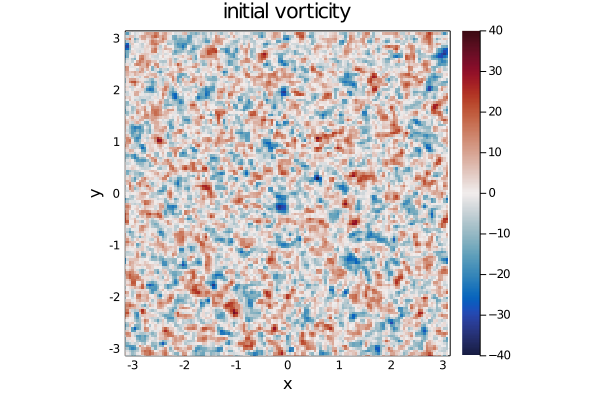

In [7]:
heatmap(x, y, vs.zeta,
         aspectratio = 1,
              c = :balance,
           clim = (-40, 40),
          xlims = (-L/2, L/2),
          ylims = (-L/2, L/2),
         xticks = -3:3,
         yticks = -3:3,
         xlabel = "x",
         ylabel = "y",
          title = "initial vorticity",
     framestyle = :box)

## Diagnostics

Create Diagnostics -- `energy` and `enstrophy` functions are imported at the top.

In [8]:
E = Diagnostic(energy, prob; nsteps=nsteps)
Z = Diagnostic(enstrophy, prob; nsteps=nsteps)
diags = [E, Z] # A list of Diagnostics types passed to "stepforward!" will  be updated every timestep.
nothing # hide

## Output

We choose folder for outputing `.jld2` files and snapshots (`.png` files).

In [9]:
filepath = "."
plotpath = "./plots_decayingTwoDNavierStokes"
plotname = "snapshots"
filename = joinpath(filepath, "decayingTwoDNavierStokes.jld2")
nothing # hide

Do some basic file management

In [10]:
if isfile(filename); rm(filename); end
if !isdir(plotpath); mkdir(plotpath); end
nothing # hide

And then create Output

In [11]:
get_sol(prob) = Array(prob.sol) # extracts the Fourier-transformed solution
get_u(prob) = Array(irfft(im*gr.l.*gr.invKrsq.*sol, gr.nx))
out = Output(prob, filename, (:sol, get_sol), (:u, get_u))
saveproblem(out)
nothing # hide

## Visualizing the simulation

We initialize a plot with the vorticity field and the time-series of
energy and enstrophy diagnostics.

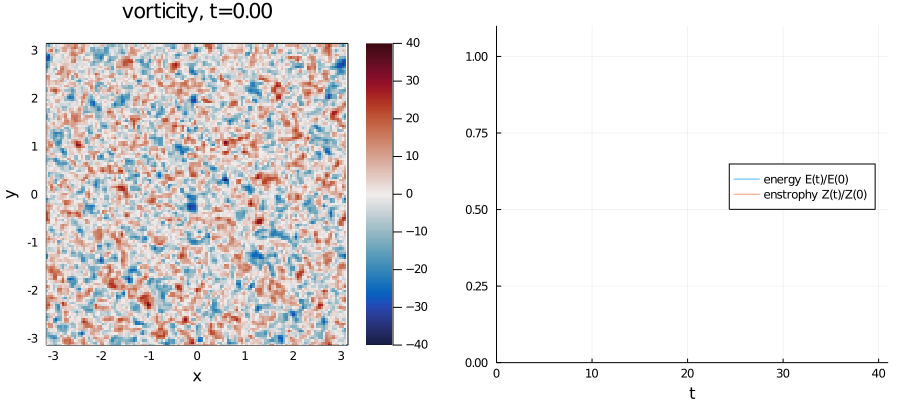

In [12]:
p1 = heatmap(x, y, vs.zeta,
         aspectratio = 1,
                   c = :balance,
                clim = (-40, 40),
               xlims = (-L/2, L/2),
               ylims = (-L/2, L/2),
              xticks = -3:3,
              yticks = -3:3,
              xlabel = "x",
              ylabel = "y",
               title = "vorticity, t="*@sprintf("%.2f", cl.t),
          framestyle = :box)

p2 = plot(2, # this means "a plot with two series"
               label = ["energy E(t)/E(0)" "enstrophy Z(t)/Z(0)"],
              legend = :right,
           linewidth = 2,
               alpha = 0.7,
              xlabel = "t",
               xlims = (0, 41),
               ylims = (0, 1.1))

l = @layout grid(1, 2)
p = plot(p1, p2, layout = l, size = (900, 400))

## Time-stepping the `Problem` forward

We time-step the `Problem` forward in time.

In [13]:
startwalltime = time()

anim = @animate for j = 0:Int(nsteps/nsubs)

  log = @sprintf("step: %04d, t: %d, ΔE: %.4f, ΔZ: %.4f, walltime: %.2f min",
      cl.step, cl.t, E.data[E.i]/E.data[1], Z.data[Z.i]/Z.data[1], (time()-startwalltime)/60)

  if j%(1000/nsubs)==0; println(log) end

  p[1][1][:z] = vs.zeta
  p[1][:title] = "vorticity, t="*@sprintf("%.2f", cl.t)
  push!(p[2][1], E.t[E.i], E.data[E.i]/E.data[1])
  push!(p[2][2], Z.t[Z.i], Z.data[Z.i]/Z.data[1])

  stepforward!(prob, diags, nsubs)
  TwoDNavierStokes.updatevars!(prob)

end

mp4(anim, "twodturb.mp4", fps=18)

step: 0000, t: 0, ΔE: 1.0000, ΔZ: 1.0000, walltime: 0.01 min
step: 1000, t: 10, ΔE: 0.9676, ΔZ: 0.1663, walltime: 0.21 min
step: 2000, t: 20, ΔE: 0.9658, ΔZ: 0.1214, walltime: 0.38 min
step: 3000, t: 30, ΔE: 0.9651, ΔZ: 0.1025, walltime: 0.55 min
step: 4000, t: 40, ΔE: 0.9640, ΔZ: 0.0760, walltime: 0.71 min
┌ Info: Saved animation to 
│   fn = /home/runner/work/GeophysicalFlows.jl/GeophysicalFlows.jl/docs/src/generated/twodturb.mp4
└ @ Plots /home/runner/.julia/packages/Plots/6RLiv/src/animation.jl:104


Plots.AnimatedGif("/home/runner/work/GeophysicalFlows.jl/GeophysicalFlows.jl/docs/src/generated/twodturb.mp4")

Last we save the output.

In [14]:
saveoutput(out)

## Radial energy spectrum

After the simulation is done we plot the radial energy spectrum to illustrate
how `FourierFlows.radialspectrum` can be used,

In [15]:
E  = @. 0.5*(vs.u^2 + vs.v^2) # energy density
Eh = rfft(E)                  # Fourier transform of energy density
kr, Ehr = FourierFlows.radialspectrum(Eh, gr, refinement=1) # compute radial specturm of `Eh`
nothing # hide

and we plot it.

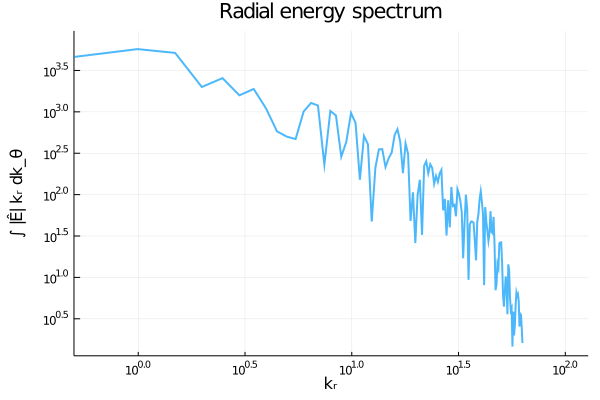

In [16]:
plot(kr, abs.(Ehr),
    linewidth = 2,
        alpha = 0.7,
       xlabel = "kᵣ", ylabel = "∫ |Ê| kᵣ dk_θ",
        xlims = (5e-1, gr.nx),
       xscale = :log10, yscale = :log10,
        title = "Radial energy spectrum",
       legend = false)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*